# 07 - Regional comparison

We want to check whether the stations that matter most to the network are concentrated in particular parts of the country. We use two different ideas of importance here: high betweenness means a station carries a large share of shortest paths, while an articulation point or bridge marks a place where the graph can actually split. We compare both by the four broad regions and by metro area.

The main question we are trying to answer is: **after allowing for the very different number of stations in each area, does one region still contain a larger share of vulnerable stations?**

We need three station-graph outputs:

- `stop_metrics.csv` for coordinates, geography, degree, and betweenness;
- `articulation_points.csv` for cut vertices;
- `bridges.csv` for cut edges, when that file is available.

We save the regional and metro summaries, the station-level flags, the chi-square result, the highest-betweenness stations in each region, and six comparison figures under `outputs/nb/07_regional_comparison/`. This notebook is only doing joins, aggregation, statistics, and plotting, so it should run quickly.

## 1. Find the project and set up the paths

We start by locating the repository, switching into it, and creating the shared `outputs/nb` directory. The helper also installs a package only if it is missing and can clone the project when we run in Colab. Everything below uses the `REPO`, `DATA`, and `OUT` paths defined here.

In [18]:
# --- Environment bootstrap (safe to re-run, works locally and on Google Colab) ---
import os, sys, subprocess
from pathlib import Path

print(f"Python {sys.version.split()[0]} -> {sys.executable}")

def _ensure(*pkgs):
    """Install only the packages that are actually missing."""
    import importlib.util
    alias = {"scikit-learn": "sklearn", "python-louvain": "community",
             "python-bidi": "bidi", "node2vec": "node2vec"}
    missing = [p for p in pkgs
               if importlib.util.find_spec(alias.get(p, p.replace("-", "_"))) is None]
    if missing:
        print("Installing missing packages:", ", ".join(missing))
        print("Using interpreter:", sys.executable)
        subprocess.run([sys.executable, "-m", "pip", "install",
                        "--disable-pip-version-check", *missing],
                       check=True, timeout=900)

def find_repo_root():
    """Find the repo locally; on Colab, clone it."""
    here = Path(os.getcwd()).resolve()
    for cand in [here, *here.parents]:
        if (cand / "israel-public-transportation").is_dir():
            return cand
    target = Path("/content/israel-transit-network-resilience")
    if not target.exists():
        subprocess.run(["git", "clone", "--depth", "1",
                        "https://github.com/seanfourman/israel-transit-network-resilience.git",
                        str(target)], check=True)
    return target

REPO = find_repo_root()
os.chdir(REPO)
DATA = REPO / "israel-public-transportation"
OUT = REPO / "outputs" / "nb"
OUT.mkdir(parents=True, exist_ok=True)
print("Repo root:", REPO)

Python 3.14.5 -> /Users/seanfourman/Desktop/israel-transit-network-resilience/.venv/bin/python
Repo root: /Users/seanfourman/Desktop/israel-transit-network-resilience


## 2. Imports and choices we may want to change

Here we load the tabular, plotting, and statistical packages and create this notebook's own `tables` and `figures` folders.

We are keeping the main choices together:

- `CRITICAL_QUANTILE = 0.90`: a critical station is at or above the network-wide 90th percentile of betweenness;
- `MIN_REGION_N = 100`: groups below this size get a warning instead of being treated like stable estimates;
- `WILSON_Z = 1.96`: use 95% Wilson intervals for the critical-station shares.

Keeping the cutoff global is important. If we calculated a separate 90th percentile inside every region, every region would contain 10% critical stations by construction and there would be nothing left to compare.

In [19]:
_ensure("pandas", "numpy", "matplotlib", "seaborn", "scipy")

import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=1.05)
pd.set_option("display.width", 160)

# ---- Tunables -------------------------------------------------------------------
CRITICAL_QUANTILE = 0.90   # "critical" = betweenness in the top 10% of the whole network
MIN_REGION_N      = 100    # below this many stops, a group is flagged as small-sample
WILSON_Z          = 1.96   # 95% confidence interval on every reported share

# ---- Stage folders --------------------------------------------------------------
STAGE   = OUT / "07_regional_comparison"
TABLES  = STAGE / "tables"
FIGURES = STAGE / "figures"
TABLES.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)

print("Stage folder:", STAGE)

Stage folder: /Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb/07_regional_comparison


## 3. Make the Hebrew labels readable

The matplotlib build we are using already handles Hebrew text direction, so we should pass Hebrew strings in their normal logical order. `fix_he` is therefore intentionally a no-op. This cell selects a font with Hebrew glyphs, turns off awkward scientific-offset labels, and removes any old `Text.set_text` patch that might reverse the labels a second time.

In [20]:
# Stop names are Hebrew. This matplotlib build applies the Unicode bidi algorithm itself,
# so Hebrew renders correctly when the raw (logical-order) string is passed to matplotlib.
# We do not pre-reorder it with python-bidi because that would reverse it a second time.
# fix_he is a no-op here, and we only select a Hebrew-capable font. (If Hebrew renders
# reversed on some other matplotlib build that has no native bidi, that build would need
# get_display; this one does not.)
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.text as mtext

def fix_he(text):
    """No-op: matplotlib reorders Hebrew itself on this build; pre-reordering would reverse it."""
    return text

def install_hebrew():
    # Arial exists on Windows; DejaVu Sans ships with matplotlib and covers Hebrew.
    matplotlib.rcParams["font.family"] = ["Arial", "DejaVu Sans"]
    matplotlib.rcParams["axes.unicode_minus"] = False
    # Write axis numbers as plain decimals - never scientific notation (no "1e-4") and no
    # "+1e-4"-style offset labels, so small values like betweenness read literally.
    matplotlib.rcParams["axes.formatter.useoffset"] = False
    matplotlib.rcParams["axes.formatter.limits"] = (-7, 7)
    # If an earlier run left a bidi patch on Text.set_text, remove it so labels render raw.
    if hasattr(mtext.Text, "_orig_set_text"):
        mtext.Text.set_text = mtext.Text._orig_set_text

install_hebrew()

## 4. Keep geography consistent across plots

We define one order, one English label, and one color for every region and metro area. Without these mappings, sorting a table could make the same place change color from one chart to the next. The helper functions also give unknown values a safe fallback, and `annotate_bars` puts the sample size above each bar.

In [21]:
REGION_ORDER = ["מרכז", "צפון", "דרום", "ירושלים"]
REGION_EN = {"מרכז": "Center", "צפון": "North",
             "דרום": "South", "ירושלים": "Jerusalem"}
REGION_COLORS = {"מרכז": "#2563eb", "צפון": "#16a34a",
                 "דרום": "#dc2626", "ירושלים": "#d97706"}

METRO_EN = {"תל אביב": "Tel Aviv", "חיפה": "Haifa", "ירושלים": "Jerusalem",
            "באר שבע": "Be'er Sheva", "פריפריה": "Periphery"}
METRO_COLORS = {"תל אביב": "#2563eb", "חיפה": "#0891b2", "ירושלים": "#d97706",
                "באר שבע": "#dc2626", "פריפריה": "#6b7280"}

GREY = "#6b7280"

def region_label(name):
    """English label for a region, falling back to display-ordered Hebrew."""
    return REGION_EN.get(name, fix_he(name))

def metro_label(name):
    return METRO_EN.get(name, fix_he(name))

def region_color(name):
    return REGION_COLORS.get(name, GREY)

def metro_color(name):
    return METRO_COLORS.get(name, GREY)

def in_region_order(values):
    """Sort region names into the canonical order; unknown names go last, alphabetically."""
    known = [r for r in REGION_ORDER if r in set(values)]
    rest = sorted(v for v in set(values) if v not in REGION_ORDER)
    return known + rest

def annotate_bars(ax, bars, texts, pad=0.02, fontsize=9):
    """Write a short group-size label just above each bar."""
    top = ax.get_ylim()[1]
    for bar, txt in zip(bars, texts):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + top * pad,
                txt, ha="center", va="bottom", fontsize=fontsize, color="#334155")

print("label helpers ready")

label helpers ready


## 5. Load and check the station-level inputs

We locate `stop_metrics.csv`, `articulation_points.csv`, and, if it exists, `bridges.csv` under `outputs/nb`. The search prefers the expected stage but excludes this notebook's own folder so a rerun cannot accidentally read its output back as input.

The centrality table sometimes names the sampled measure `approx_betweenness`; we alias that to `betweenness` here and keep the fact that it is sampled in mind when interpreting the result. We also check the required columns, coerce numeric fields, fill missing geography with `Unknown`, and print the number of stations loaded per region. We want schema problems to stop the run here rather than appear later as a misleading empty plot.

In [22]:
def find_artifact(filename, prefer_prefix, produced_by):
    """Locate a file written by an earlier notebook stage under outputs/nb."""
    candidates = sorted({p for p in OUT.rglob(filename) if STAGE not in p.parents})
    if not candidates:
        raise FileNotFoundError(
            f"{filename} not found anywhere under {OUT} - "
            f"run notebook {produced_by} first, it writes this file.")
    preferred = [p for p in candidates
                 if p.relative_to(OUT).parts[0].startswith(prefer_prefix)]
    chosen = (preferred or candidates)[0]
    if len(candidates) > 1:
        print(f"  note: found {len(candidates)} copies of {filename}; using {chosen}")
    return chosen

METRICS_PATH = find_artifact("stop_metrics.csv", "04", "04_centrality_analysis")
AP_PATH = find_artifact("articulation_points.csv", "03", "03_network_descriptive_analysis")

metrics = pd.read_csv(METRICS_PATH, dtype={"stop_id": str}, encoding="utf-8-sig")
ap_df = pd.read_csv(AP_PATH, dtype={"stop_id": str}, encoding="utf-8-sig")

try:
    BRIDGES_PATH = find_artifact("bridges.csv", "03", "03_network_descriptive_analysis")
    bridges = pd.read_csv(BRIDGES_PATH,
                          dtype={"from_stop": str, "to_stop": str},
                          encoding="utf-8-sig")
except FileNotFoundError:
    BRIDGES_PATH, bridges = None, None
    print("  bridges.csv not available - the bridge columns will be skipped.")

# Notebook 04 exports the sampled estimate under the name `approx_betweenness`
# (the name records that it is a k-sample estimate, not exact betweenness).
# Alias it so this notebook works with either schema.
if "betweenness" not in metrics.columns and "approx_betweenness" in metrics.columns:
    metrics["betweenness"] = metrics["approx_betweenness"]
    print("  note: aliased 'approx_betweenness' -> 'betweenness' (sampled estimate)")

# Fail loudly and early if the upstream schema is not what we expect.
for col in ("stop_id", "region", "metro", "degree", "betweenness", "lat", "lon"):
    if col not in metrics.columns:
        raise KeyError(f"'{col}' missing from {METRICS_PATH.name}. "
                       f"Columns present: {list(metrics.columns)}")

for col in ("degree", "betweenness", "lat", "lon"):
    metrics[col] = pd.to_numeric(metrics[col], errors="coerce")
metrics["degree"] = metrics["degree"].fillna(0)
metrics["betweenness"] = metrics["betweenness"].fillna(0)
for col in ("region", "metro"):
    metrics[col] = metrics[col].fillna("").replace("", "Unknown")

print(f"stops loaded      : {len(metrics):,}  <- {METRICS_PATH}")
print(f"articulation pts  : {len(ap_df):,}  <- {AP_PATH}")
print(f"bridges           : {0 if bridges is None else len(bridges):,}")
print("stops per region  :")
print(metrics["region"].value_counts().to_string())

  note: aliased 'approx_betweenness' -> 'betweenness' (sampled estimate)
stops loaded      : 30,463  <- /Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb/04_centrality_analysis/tables/stop_metrics.csv
articulation pts  : 900  <- /Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb/03_descriptive_analysis/tables/articulation_points.csv
bridges           : 971
stops per region  :
region
Center       12970
North        10025
Jerusalem     3743
South         3725


## 6. Define the two kinds of critical station

We compute the 90th-percentile betweenness cutoff once across all stations and create three flags:

- `is_critical`: betweenness at or above that global cutoff;
- `is_ap`: the station appears in the articulation-point table;
- `is_critical_broad`: the union of the two.

We keep the top-betweenness flag and the articulation flag separate because they answer different questions. Betweenness is a load or brokerage measure; an articulation point is a strict connectivity failure point. The printed overlap tells us how often those ideas agree.

The cell also prints the actual selected share. This catches the edge case where many stations are tied at the percentile cutoff, or where the cutoff is zero because too much of the graph was outside the component used for betweenness.

In [23]:
ap_set = set(ap_df["stop_id"].astype(str))
metrics["is_ap"] = metrics["stop_id"].astype(str).isin(ap_set)

BTW_THRESHOLD = float(metrics["betweenness"].quantile(CRITICAL_QUANTILE))
metrics["is_critical"] = metrics["betweenness"] >= BTW_THRESHOLD
metrics["is_critical_broad"] = metrics["is_critical"] | metrics["is_ap"]

n_total = len(metrics)
n_crit = int(metrics["is_critical"].sum())
n_ap = int(metrics["is_ap"].sum())
n_both = int((metrics["is_critical"] & metrics["is_ap"]).sum())

print(f"betweenness p{CRITICAL_QUANTILE*100:.0f} threshold : {BTW_THRESHOLD:.8f}")
print(f"critical (top betweenness)   : {n_crit:,}  ({100*n_crit/n_total:.1f}% of all stops)")
print(f"articulation points matched  : {n_ap:,}  ({100*n_ap/n_total:.1f}%)")
print(f"both critical and AP         : {n_both:,}")
print(f"union (is_critical_broad)    : {int(metrics['is_critical_broad'].sum()):,}")

if BTW_THRESHOLD <= 0:
    print("\nWARNING: the p90 threshold is 0, meaning more than 10% of stops have zero "
          "betweenness. Every zero-betweenness stop is being counted as critical - "
          "raise CRITICAL_QUANTILE or restrict to the largest component before trusting this.")
if n_ap == 0:
    print("\nWARNING: no articulation point matched a stop_id in stop_metrics.csv - "
          "the two upstream files may use different id formats.")

betweenness p90 threshold : 0.00058890
critical (top betweenness)   : 3,047  (10.0% of all stops)
articulation points matched  : 900  (3.0%)
both critical and AP         : 118
union (is_critical_broad)    : 3,829


## 7. Count cut edges touching each region

For each graph-theory bridge, we look up the region of both endpoints. A bridge inside one region counts once for that region; a bridge crossing a boundary counts once for each distinct region it touches. This gives an edge-level fragility count that can be normalized by the number of stations later. If the bridge table is unavailable, we leave these columns out rather than inventing zeros.

In [24]:
bridge_counts = None
if bridges is not None and len(bridges) and {"from_stop", "to_stop"} <= set(bridges.columns):
    region_of = metrics.drop_duplicates("stop_id").set_index("stop_id")["region"]
    touched = []
    for a, b in zip(bridges["from_stop"].map(region_of), bridges["to_stop"].map(region_of)):
        touched.extend({r for r in (a, b) if isinstance(r, str)})
    bridge_counts = pd.Series(touched, dtype="object").value_counts()
    print("bridges touching each region:")
    print(bridge_counts.to_string())
else:
    print("no bridge data - skipping the bridge columns")

bridges touching each region:
Center       356
North        275
Jerusalem    225
South        121


## 8. Build the regional comparison table

The `summarize` helper groups the station table and calculates counts, mean and maximum centrality, critical and articulation-point rates, and each region's share of all stations and all critical stations. It also adds a 95% Wilson interval around the critical-station rate and flags groups with fewer than `MIN_REGION_N` stations.

Raw counts and rates need to stay side by side: the center can contain many critical stations because it is large while still having a lower critical-station rate. If bridge counts are available, we add both the count touching the region and the rate per 1,000 stations. We sort the result by criticality, print it, and save `regional_summary.csv` plus the full station table with its flags.

In [25]:
def wilson_ci(k, n, z=WILSON_Z):
    """95% Wilson score interval (in percent) for k successes out of n."""
    if n == 0:
        return (np.nan, np.nan)
    p = k / n
    denom = 1 + z**2 / n
    center = (p + z**2 / (2 * n)) / denom
    half = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / denom
    return (100 * max(0.0, center - half), 100 * min(1.0, center + half))

def summarize(df, key):
    """Aggregate stop-level flags into one row per group (region or metro)."""
    s = df.groupby(key).agg(
        total_stops=("stop_id", "count"),
        critical_stops=("is_critical", "sum"),
        critical_broad_stops=("is_critical_broad", "sum"),
        ap_stops=("is_ap", "sum"),
        avg_degree=("degree", "mean"),
        avg_betweenness=("betweenness", "mean"),
        max_betweenness=("betweenness", "max"),
    ).reset_index()
    for c in ("critical_stops", "critical_broad_stops", "ap_stops"):
        s[c] = s[c].astype(int)
    s["pct_critical"] = (100 * s["critical_stops"] / s["total_stops"]).round(2)
    s["pct_critical_broad"] = (100 * s["critical_broad_stops"] / s["total_stops"]).round(2)
    s["pct_ap"] = (100 * s["ap_stops"] / s["total_stops"]).round(2)
    # share of the network's critical stops that sit in this group
    s["share_of_all_critical"] = (100 * s["critical_stops"] / max(1, n_crit)).round(1)
    s["share_of_all_stops"] = (100 * s["total_stops"] / n_total).round(1)
    ci = [wilson_ci(k, n) for k, n in zip(s["critical_stops"], s["total_stops"])]
    s["pct_critical_lo"] = [round(lo, 2) for lo, _ in ci]
    s["pct_critical_hi"] = [round(hi, 2) for _, hi in ci]
    s["small_sample"] = s["total_stops"] < MIN_REGION_N
    s["avg_degree"] = s["avg_degree"].round(3)
    s["avg_betweenness"] = s["avg_betweenness"].round(8)
    return s.sort_values("pct_critical", ascending=False).reset_index(drop=True)

region_summary = summarize(metrics, "region")
if bridge_counts is not None:
    region_summary["bridges_touching"] = (region_summary["region"]
                                          .map(bridge_counts).fillna(0).astype(int))
    region_summary["bridges_per_1000_stops"] = (
        1000 * region_summary["bridges_touching"] / region_summary["total_stops"]).round(2)

region_summary.to_csv(TABLES / "regional_summary.csv", index=False, encoding="utf-8-sig")
metrics.to_csv(TABLES / "stops_with_region.csv", index=False, encoding="utf-8-sig")

print(region_summary.to_string(index=False))

flagged = region_summary[region_summary["small_sample"]]
if len(flagged):
    print(f"\nSMALL SAMPLE (< {MIN_REGION_N} stops) - do not quote these percentages:")
    print(flagged[["region", "total_stops", "pct_critical"]].to_string(index=False))
else:
    print(f"\nNo region falls below {MIN_REGION_N} stops - all regional shares are on "
          "thousands of stops and are statistically stable.")
print(f"\nsaved -> {TABLES / 'regional_summary.csv'}")

   region  total_stops  critical_stops  critical_broad_stops  ap_stops  avg_degree  avg_betweenness  max_betweenness  pct_critical  pct_critical_broad  pct_ap  share_of_all_critical  share_of_all_stops  pct_critical_lo  pct_critical_hi  small_sample  bridges_touching  bridges_per_1000_stops
    North        10025            1158                  1399       273       3.161         0.000490         0.043863         11.55               13.96    2.72                   38.0                32.9            10.94            12.19         False               275                   27.43
Jerusalem         3743             383                   573       211       3.450         0.000444         0.087533         10.23               15.31    5.64                   12.6                12.3             9.30            11.24         False               225                   60.11
    South         3725             350                   450       114       3.146         0.000389         0.071646        

## 9. Repeat the aggregation by metro area

The four broad regions mix dense cities with rural surroundings, so we run the same `summarize` function on the metro label. This separates Tel Aviv, Haifa, Jerusalem, and Be'er Sheva from the remaining periphery. We print any small groups before saving `metro_summary.csv`, because a high percentage based on very few stations would not be a useful result.

In [26]:
metro_summary = summarize(metrics, "metro")
metro_summary.to_csv(TABLES / "metro_summary.csv", index=False, encoding="utf-8-sig")
print(metro_summary.to_string(index=False))

flagged_metro = metro_summary[metro_summary["small_sample"]]
if len(flagged_metro):
    print(f"\nSMALL SAMPLE (< {MIN_REGION_N} stops):")
    print(flagged_metro[["metro", "total_stops", "pct_critical",
                         "pct_critical_lo", "pct_critical_hi"]].to_string(index=False))
else:
    print(f"\nNo metro area falls below {MIN_REGION_N} stops.")
print(f"\nsaved -> {TABLES / 'metro_summary.csv'}")

     metro  total_stops  critical_stops  critical_broad_stops  ap_stops  avg_degree  avg_betweenness  max_betweenness  pct_critical  pct_critical_broad  pct_ap  share_of_all_critical  share_of_all_stops  pct_critical_lo  pct_critical_hi  small_sample
     Haifa         4023             491                   582       112       3.165         0.000492         0.031288         12.20               14.47    2.78                   16.1                13.2            11.23            13.25         False
 Jerusalem         3474             352                   537       201       3.361         0.000455         0.087533         10.13               15.46    5.79                   11.6                11.4             9.17            11.18         False
 Periphery        12627            1253                  1516       301       3.252         0.000420         0.112456          9.92               12.01    2.38                   41.1                41.5             9.41            10.46         Fa

## 10. Test whether region and criticality are associated

We form a region-by-critical-status contingency table and run a chi-square test of independence. With more than 30,000 stations, the p-value can become tiny even for a very small difference, so we also calculate Cramer's V and the spread between the highest and lowest regional rates. Those are the quantities we use to judge the practical size of the pattern. The test and its expected-count check are saved to `regional_significance.csv`.

In [27]:
from scipy.stats import chi2_contingency

contingency = pd.crosstab(metrics["region"], metrics["is_critical"])
chi2, p_value, dof, expected = chi2_contingency(contingency)
n_obs = int(contingency.values.sum())
cramers_v = float(np.sqrt(chi2 / (n_obs * (min(contingency.shape) - 1))))
spread = float(region_summary["pct_critical"].max() - region_summary["pct_critical"].min())

sig = pd.DataFrame([{
    "test": "chi-square independence (region x is_critical)",
    "chi2": round(chi2, 2),
    "dof": int(dof),
    "p_value": p_value,
    "n": n_obs,
    "cramers_v": round(cramers_v, 4),
    "pct_critical_spread_points": round(spread, 2),
    "min_expected_count": round(float(expected.min()), 1),
}])
sig.to_csv(TABLES / "regional_significance.csv", index=False, encoding="utf-8-sig")
print(sig.T.to_string(header=False))

print("\nInterpretation:")
print(f"  p = {p_value:.3g} -> the regions differ statistically; with n={n_obs:,}, "
      "the effect size matters more than the p-value alone.")
print(f"  Cramer's V = {cramers_v:.3f} -> "
      + ("negligible" if cramers_v < 0.1 else "small" if cramers_v < 0.3
         else "moderate" if cramers_v < 0.5 else "large") + " association.")
print(f"  spread between the highest and lowest region: {spread:.1f} percentage points.")

test                        chi-square independence (region x is_critical)
chi2                                                                 45.56
dof                                                                      3
p_value                                                                0.0
n                                                                    30463
cramers_v                                                           0.0387
pct_critical_spread_points                                            2.64
min_expected_count                                                   372.6

Interpretation:
  p = 7.05e-10 -> the regions differ statistically; with n=30,463, the effect size matters more than the p-value alone.
  Cramer's V = 0.039 -> negligible association.
  spread between the highest and lowest region: 2.6 percentage points.


## 11. Plot counts and rates separately

The left panel shows the number of top-betweenness stations in each region; the right panel shows the percentage within that region. We add the Wilson intervals to the percentage panel, write `n` above the bars, and hatch any group below the sample-size cutoff. We need both panels because the absolute infrastructure burden and the within-region concentration can point in different directions.

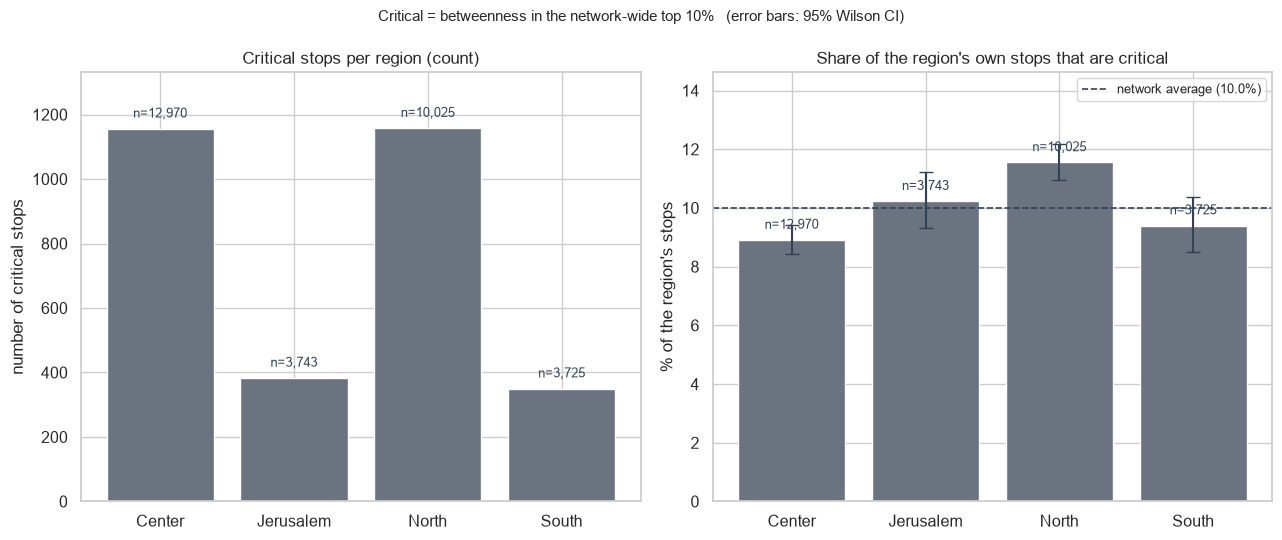

saved -> /Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb/07_regional_comparison/figures/critical_stations_by_region.png


In [28]:
reg = region_summary.set_index("region").loc[in_region_order(region_summary["region"])].reset_index()
labels = [region_label(r) for r in reg["region"]]
colors = [region_color(r) for r in reg["region"]]
hatches = ["//" if flag else "" for flag in reg["small_sample"]]
n_texts = [f"n={int(v):,}" for v in reg["total_stops"]]

yerr = np.vstack([
    np.clip(reg["pct_critical"] - reg["pct_critical_lo"], 0, None),
    np.clip(reg["pct_critical_hi"] - reg["pct_critical"], 0, None),
])

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

bars = axes[0].bar(labels, reg["critical_stops"], color=colors, edgecolor="white", hatch=hatches)
axes[0].set_title("Critical stops per region (count)")
axes[0].set_ylabel("number of critical stops")
axes[0].margins(y=0.15)
annotate_bars(axes[0], bars, n_texts)

bars2 = axes[1].bar(labels, reg["pct_critical"], color=colors, edgecolor="white",
                    hatch=hatches, yerr=yerr, capsize=5, ecolor="#334155")
axes[1].axhline(100 * n_crit / n_total, color="#334155", ls="--", lw=1.2,
                label=f"network average ({100*n_crit/n_total:.1f}%)")
axes[1].set_title("Share of the region's own stops that are critical")
axes[1].set_ylabel("% of the region's stops")
axes[1].margins(y=0.20)
axes[1].legend(fontsize=9)
annotate_bars(axes[1], bars2, n_texts)

fig.suptitle(f"Critical = betweenness in the network-wide top {100*(1-CRITICAL_QUANTILE):.0f}%"
             "   (error bars: 95% Wilson CI)", fontsize=11)
plt.tight_layout()
plt.savefig(FIGURES / "critical_stations_by_region.png", dpi=150)
plt.show()
print("saved ->", FIGURES / "critical_stations_by_region.png")

## 12. Compare structural failure points

This figure switches from high betweenness to strict graph cuts. The first panel plots the share of stations that are articulation points. When bridge data is present, the second plots bridges touching the region per 1,000 stations. Looking at both helps us distinguish a region with busy hubs from a region whose topology depends on a small number of irreplaceable nodes or edges.

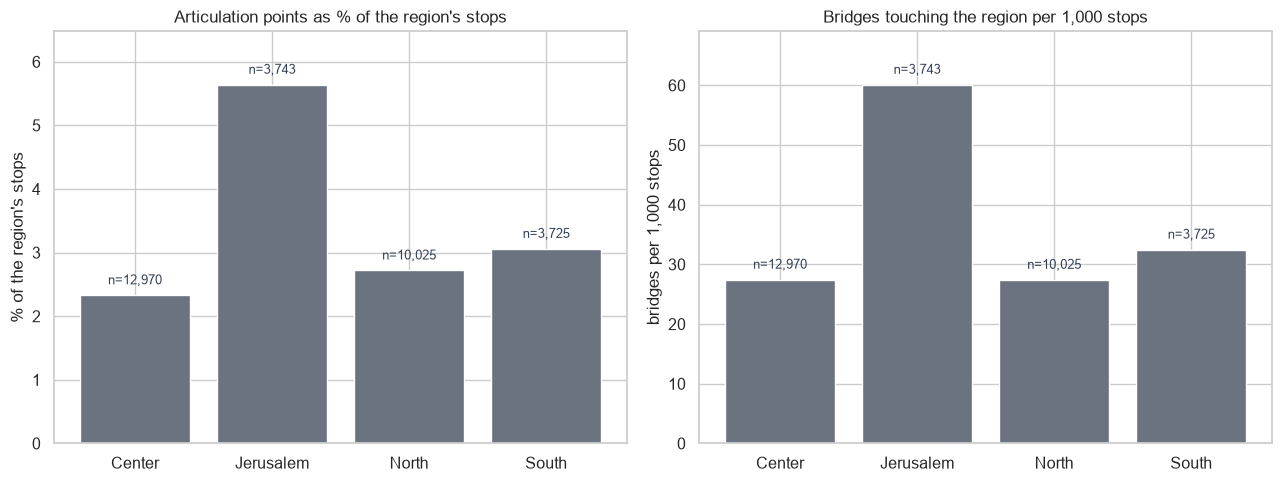

saved -> /Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb/07_regional_comparison/figures/ap_and_bridges_by_region.png


In [29]:
has_bridges = "bridges_per_1000_stops" in reg.columns
ncols = 2 if has_bridges else 1
fig, axes = plt.subplots(1, ncols, figsize=(6.5 * ncols, 5))
axes = np.atleast_1d(axes)

b = axes[0].bar(labels, reg["pct_ap"], color=colors, edgecolor="white", hatch=hatches)
axes[0].set_title("Articulation points as % of the region's stops")
axes[0].set_ylabel("% of the region's stops")
axes[0].margins(y=0.15)
annotate_bars(axes[0], b, n_texts)

if has_bridges:
    b2 = axes[1].bar(labels, reg["bridges_per_1000_stops"], color=colors,
                     edgecolor="white", hatch=hatches)
    axes[1].set_title("Bridges touching the region per 1,000 stops")
    axes[1].set_ylabel("bridges per 1,000 stops")
    axes[1].margins(y=0.15)
    annotate_bars(axes[1], b2, n_texts)

plt.tight_layout()
plt.savefig(FIGURES / "ap_and_bridges_by_region.png", dpi=150)
plt.show()
print("saved ->", FIGURES / "ap_and_bridges_by_region.png")

## 13. Look past the regional averages

We plot mean betweenness on the left and the nonzero station-level distributions on a logarithmic scale on the right. The boxplots hide outliers so the regional bodies remain visible, and the dashed line marks the single global 90th-percentile cutoff used for `is_critical`. Dropping zeros is only for the log plot; the zeros remain in every summary and threshold calculation.

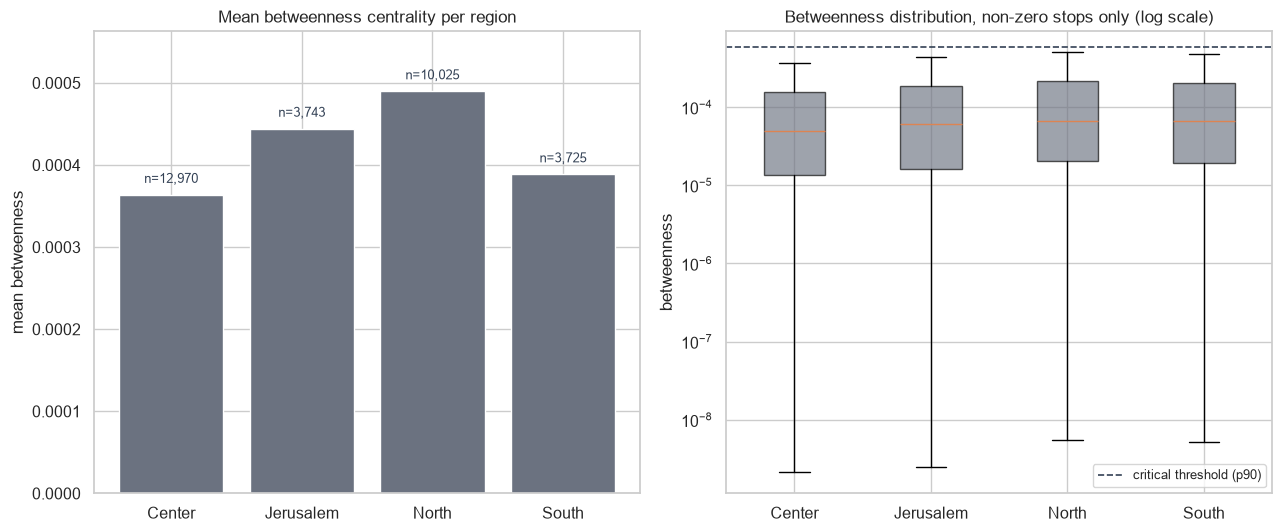

saved -> /Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb/07_regional_comparison/figures/avg_betweenness_by_region.png


In [30]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

b = axes[0].bar(labels, reg["avg_betweenness"], color=colors, edgecolor="white", hatch=hatches)
axes[0].set_title("Mean betweenness centrality per region")
axes[0].set_ylabel("mean betweenness")
axes[0].margins(y=0.15)
annotate_bars(axes[0], b, n_texts)

order = list(reg["region"])
data = [metrics.loc[(metrics["region"] == r) & (metrics["betweenness"] > 0), "betweenness"].values
        for r in order]
parts = axes[1].boxplot(data, tick_labels=labels, showfliers=False, patch_artist=True)
for patch, c in zip(parts["boxes"], colors):
    patch.set_facecolor(c)
    patch.set_alpha(0.65)
axes[1].set_yscale("log")
axes[1].axhline(max(BTW_THRESHOLD, 1e-12), color="#334155", ls="--", lw=1.2,
                label=f"critical threshold (p{CRITICAL_QUANTILE*100:.0f})")
axes[1].set_title("Betweenness distribution, non-zero stops only (log scale)")
axes[1].set_ylabel("betweenness")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES / "avg_betweenness_by_region.png", dpi=150)
plt.show()
print("saved ->", FIGURES / "avg_betweenness_by_region.png")

## 14. Check the geographic assignment on a map

We draw every station with usable coordinates in its assigned regional color and then overlay critical stations in black. This lets us check that the latitude-based regions form the expected bands and see whether the high-betweenness stations follow recognizable intercity corridors. The code prints how many stations had to be omitted because of missing coordinates.

stops without coordinates (dropped from the map): 0


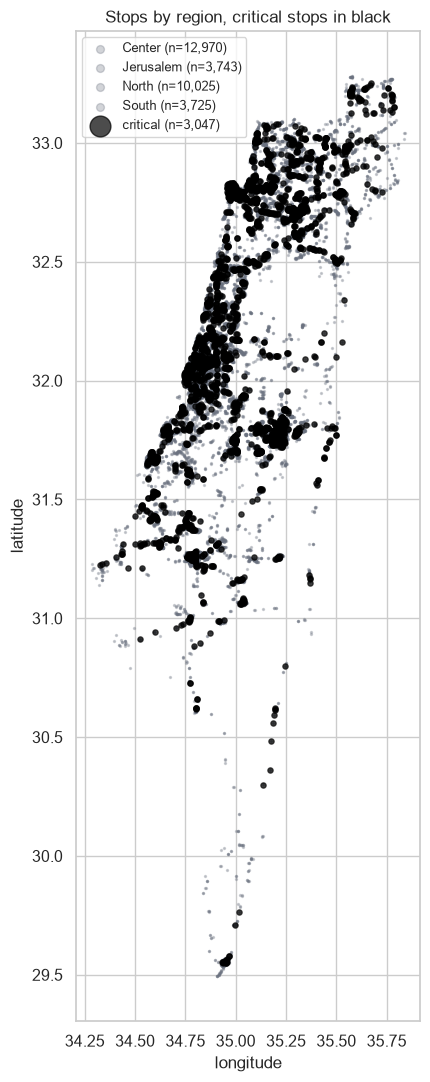

saved -> /Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb/07_regional_comparison/figures/stations_map_by_region.png


In [31]:
geo = metrics.dropna(subset=["lat", "lon"])
print(f"stops without coordinates (dropped from the map): {len(metrics) - len(geo):,}")

fig, ax = plt.subplots(figsize=(8, 11))
for r in in_region_order(geo["region"]):
    grp = geo[geo["region"] == r]
    ax.scatter(grp["lon"], grp["lat"], s=2, alpha=0.30, color=region_color(r),
               label=f"{region_label(r)} (n={len(grp):,})")

crit_geo = geo[geo["is_critical"]]
ax.scatter(crit_geo["lon"], crit_geo["lat"], s=14, color="black", alpha=0.70, zorder=5,
           label=f"critical (n={len(crit_geo):,})")

ax.set_title("Stops by region, critical stops in black")
ax.set_xlabel("longitude")
ax.set_ylabel("latitude")
ax.set_aspect(1 / np.cos(np.radians(float(geo["lat"].mean()))))
ax.legend(markerscale=4, fontsize=9, loc="upper left")
plt.tight_layout()
plt.savefig(FIGURES / "stations_map_by_region.png", dpi=150)
plt.show()
print("saved ->", FIGURES / "stations_map_by_region.png")

## 15. Put the four regional measures next to each other

This is the compact regional comparison: critical-station rate, articulation-point rate, average degree, and share of all critical stations. In the last panel we also mark each region's share of all stations. The gap between those two shares tells us whether a region is over- or under-represented among critical stations relative to its size.

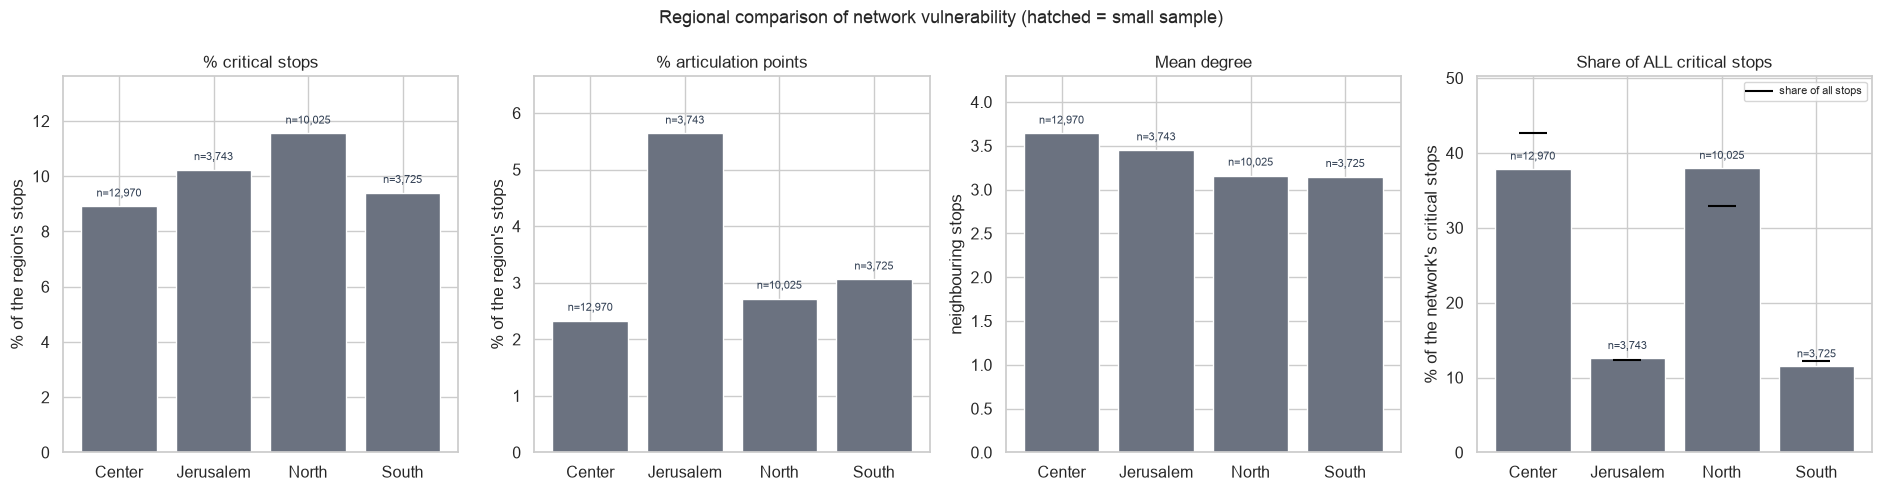

saved -> /Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb/07_regional_comparison/figures/regional_vulnerability_comparison.png


In [32]:
panels = [
    ("pct_critical", "% critical stops", "% of the region's stops"),
    ("pct_ap", "% articulation points", "% of the region's stops"),
    ("avg_degree", "Mean degree", "neighbouring stops"),
    ("share_of_all_critical", "Share of ALL critical stops", "% of the network's critical stops"),
]

fig, axes = plt.subplots(1, 4, figsize=(19, 5))
for ax, (col, title, ylab) in zip(axes, panels):
    bars = ax.bar(labels, reg[col], color=colors, edgecolor="white", hatch=hatches)
    ax.set_title(title)
    ax.set_ylabel(ylab)
    ax.margins(y=0.18)
    annotate_bars(ax, bars, n_texts, fontsize=8)
    if col == "share_of_all_critical":
        ax.scatter(labels, reg["share_of_all_stops"], color="black", marker="_", s=400,
                   zorder=6, label="share of all stops")
        ax.legend(fontsize=8)

fig.suptitle("Regional comparison of network vulnerability (hatched = small sample)", fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES / "regional_vulnerability_comparison.png", dpi=150)
plt.show()
print("saved ->", FIGURES / "regional_vulnerability_comparison.png")

## 16. Make the same compact view for metro areas

We repeat the comparison with metro groups, order them by critical-station rate, and keep the sample-size labels and hatching. This gives us a more urban interpretation than the broad north/center/south bands and makes the dense metro-versus-periphery comparison visible.

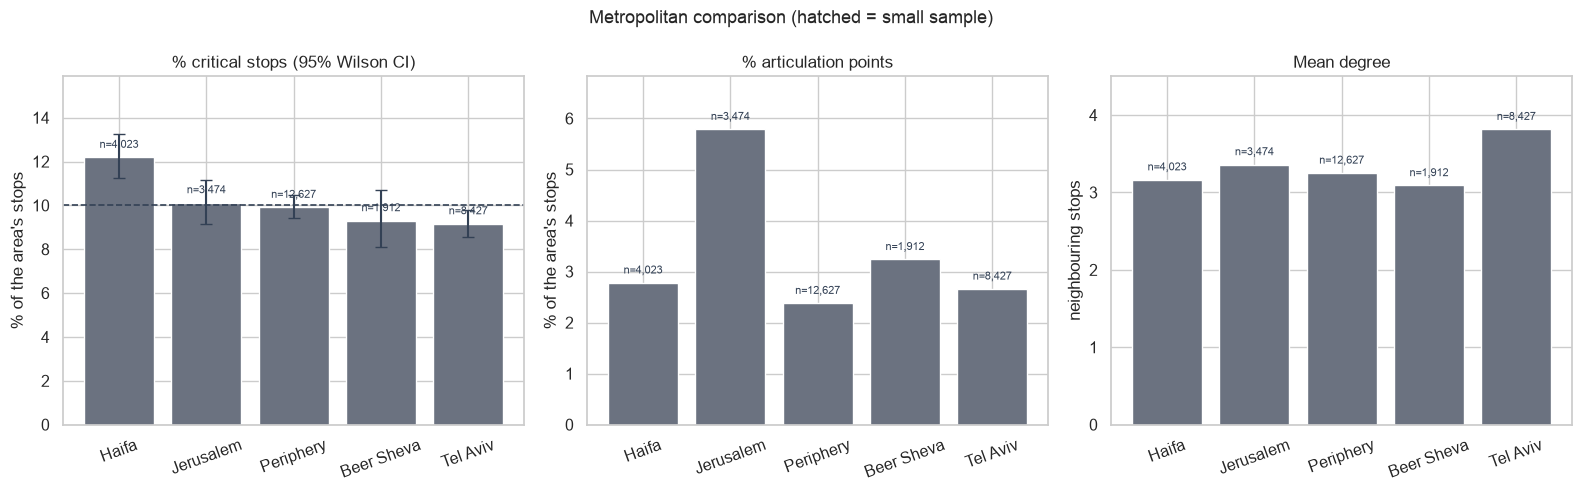

saved -> /Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb/07_regional_comparison/figures/metro_vulnerability_comparison.png


In [33]:
mt = metro_summary.copy()
m_labels = [metro_label(m) for m in mt["metro"]]
m_colors = [metro_color(m) for m in mt["metro"]]
m_hatch = ["//" if f else "" for f in mt["small_sample"]]
m_texts = [f"n={int(v):,}" for v in mt["total_stops"]]

m_yerr = np.vstack([
    np.clip(mt["pct_critical"] - mt["pct_critical_lo"], 0, None),
    np.clip(mt["pct_critical_hi"] - mt["pct_critical"], 0, None),
])

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

b0 = axes[0].bar(m_labels, mt["pct_critical"], color=m_colors, edgecolor="white",
                 hatch=m_hatch, yerr=m_yerr, capsize=4, ecolor="#334155")
axes[0].axhline(100 * n_crit / n_total, color="#334155", ls="--", lw=1.2)
axes[0].set_title("% critical stops (95% Wilson CI)")
axes[0].set_ylabel("% of the area's stops")
axes[0].margins(y=0.20)
annotate_bars(axes[0], b0, m_texts, fontsize=8)

b1 = axes[1].bar(m_labels, mt["pct_ap"], color=m_colors, edgecolor="white", hatch=m_hatch)
axes[1].set_title("% articulation points")
axes[1].set_ylabel("% of the area's stops")
axes[1].margins(y=0.18)
annotate_bars(axes[1], b1, m_texts, fontsize=8)

b2 = axes[2].bar(m_labels, mt["avg_degree"], color=m_colors, edgecolor="white", hatch=m_hatch)
axes[2].set_title("Mean degree")
axes[2].set_ylabel("neighbouring stops")
axes[2].margins(y=0.18)
annotate_bars(axes[2], b2, m_texts, fontsize=8)

for ax in axes:
    ax.tick_params(axis="x", rotation=20)

fig.suptitle("Metropolitan comparison (hatched = small sample)", fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES / "metro_vulnerability_comparison.png", dpi=150)
plt.show()
print("saved ->", FIGURES / "metro_vulnerability_comparison.png")

## 17. Inspect the stations behind the aggregates

Finally, we take the five highest-betweenness critical stations in each region and keep their name, metro, degree, betweenness, and articulation-point flag. This is a useful reality check: a regional percentage is easier to trust when we can see which junctions are driving it. We save the list and then print every artifact produced by the notebook.

In [34]:
cols = ["region", "metro", "stop_id", "stop_name", "degree", "betweenness", "is_ap"]
cols = [c for c in cols if c in metrics.columns]

top_by_region = (metrics[metrics["is_critical"]]
                 .sort_values("betweenness", ascending=False)
                 .groupby("region", group_keys=False)
                 .head(5)[cols]
                 .sort_values(["region", "betweenness"], ascending=[True, False]))

top_by_region.to_csv(TABLES / "top_critical_by_region.csv", index=False, encoding="utf-8-sig")
print(top_by_region.to_string(index=False))
print(f"\nsaved -> {TABLES / 'top_critical_by_region.csv'}")

print("\nAll artifacts written by this notebook:")
for p in sorted(STAGE.rglob("*")):
    if p.is_file():
        print("  ", p.relative_to(OUT))

   region      metro stop_id                              stop_name  degree  betweenness  is_ap
   Center  Periphery   17303              ת.התרעננות/דור אלון מגל 6      16     0.112456  False
   Center   Tel Aviv    7562               שדרות בית הלל/כניסה לעיר      29     0.065783  False
   Center   Tel Aviv   23418             רבי יהודה הנשיא/כניסה לעיר      24     0.056597  False
   Center   Tel Aviv     748                               מחלף קסם      19     0.047271  False
   Center  Periphery    4132                           צומת כפר קרע      14     0.039735  False
Jerusalem  Jerusalem   41133                               מחלף חמד      62     0.087533   True
Jerusalem  Jerusalem    7444                   דרך האר''י/ כביש 375      29     0.069168  False
Jerusalem  Jerusalem   41132                               מחלף חמד      44     0.066711  False
Jerusalem  Jerusalem    9048                 בן גוריון/שערי ירושלים      41     0.040754   True
Jerusalem  Jerusalem    9046            

## Conclusions

Here is what we get from the current tables:

1. **The regional difference is real but small.** The critical-station rates run from 8.91% in the Center to 11.55% in the North, a spread of 2.64 percentage points. Jerusalem is 10.23% and the South is 9.40%, so the result is not a simple center-versus-periphery split. The chi-square p-value is below `0.001`, but Cramer's V is only `0.0387`; with this sample size, the effect size is much more informative than significance alone.

2. **Counts and rates tell different stories.** The North has 1,158 critical stations and the Center has 1,156, almost the same count. But the North contains 32.9% of all stations and 38.0% of all critical stations, while the Center contains 42.6% of stations and 37.9% of critical stations. We need to use counts when thinking about the total amount of exposed infrastructure and rates when comparing concentration.

3. **Jerusalem stands out more clearly on strict connectivity.** Its articulation-point rate is 5.64%, compared with 2.33% in the Center, 2.72% in the North, and 3.06% in the South. It also has about 60 bridges touching the region per 1,000 stations, roughly twice the other regions. That is stronger evidence of a chain-like, low-redundancy structure than the betweenness rate alone.

4. **The metro comparison adds another pattern.** Haifa has the highest critical-station rate at 12.20%, followed by Jerusalem at 10.13%; the Periphery is 9.92%, Be'er Sheva 9.31%, and Tel Aviv 9.17%. None of these groups falls below 100 stations, so no bar is being driven by a tiny sample.

5. **We should not treat these geography labels as official districts.** They come from coordinate rules, and betweenness is a sampled estimate calculated on the largest connected component. The graph measures scheduled topology, not riders or actual closure costs. These results describe where structural roles are concentrated; they do not show a causal regional disadvantage by themselves.